## Importacion

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool

In [ ]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

In [ ]:
df.dropna(inplace=True)

In [ ]:
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

## Prueba I

CatBoost sin playlist_genre ni playlist_subgenre (si r&b y neosoul dummies)

Agregamos playlist_name y playlist_id que son buenas categoricas

Artist_id es la unica categorica de las de track y ids que agregamos

Duration_ms la sacamos y calculamos todas con duration_min

Posteriormente combinamos este modelo con los valores actuales de track_popularity de las canciones de train que tienen mismo track_name o track_id que canciones de val

#### Pequeña exploracion de datos

In [ ]:
df['track_artist'].value_counts() # -> ponele que OK para ser categorica

,count
track_artist,
7loaBLZd5m52bkYjLCc/K0y1cHim3sOy+6aFD5lisIM=,136
67F5u09C61bWrsPc9YmNiwCDOwu8tnXjEDCaPdZKl0I=,102
m5NrgbSG2Odrjci1FPsgysRE8qoxhtexiPz3ekxaqCM=,94
mOJnoGfnv0MMr0wgSVrG59i4oJMFKwkxtsa6+TCzFBo=,79
JkW2Ny6dCKXQSpNtt6h5SEw0R5NufDhLigaLODbIXbVck/NTuRV//uS6PjH2gyT8,74
...,...
S/jIl1/7RkP8Ri+hXiPdhBumkJOca0KiLjWAgw6k7p0=,1
UPdzRO/2FvKgFE2mUkCwbpoKzrLPR/4l9CTn+3bd7rA=,1
D0e7uvfZCia3EB17ZpdbhFeryIau0kRC5vr6ckYxLE0=,1


In [ ]:
df['track_album_name'].value_counts()

,count
track_album_name,
/R2Tw+WK8neGbePAvHxUv/IkqeUoSceNEOZnPbER7/g=,138
05u/TiFrwOgkC8YgI/YJ40eE9bp47CvmcOpnF/PKszL+aDoxthVTvFS1J8QcqYc4,42
FflKN1eVI+Zqms+W99XcysoyXts4povw/9I00hgzghY=,33
oIKnpiH4B58i7TL711IFcilXJBpkRzYwMJFsTN/w81ePlL+6gFB8XNwupvJ5JoXU,29
e5casBpd9ini3nvoljlNajb69KB+Hh2ri5eoZ4cvRRI=,29
...,...
9m4WaJnUfy+seFuLIVxuhfIJJqCXjDBIM9biHjU8cLw=,1
12Qo7/z8Bu9QJzWRZnA8yyvDTUz6o/fnVDpSFUW6euFlu3jRkVy1vyJspa/yBJMa,1
jBtdE94rwdX3q3U6cUKYmyTdC59narwFX4W7ig5i/Nc=,1


In [ ]:
df['track_album_id'].value_counts()

,count
track_album_id,
iBTTDMxJXPGwkLwGulbWZqJxr0ddQYXdpvyPcfjJAc7rBcmobTVfM4AO2dj9aB1i,42
36/SYe6gHI3eN18m8cDZHmhtl13nc+5yAdqdNpquk154AbjEWCQfkEWolhsCALkr,29
OZb72ibus1d1dDz4NL62DWkJGY/CvYbDbm05YAK1x64ttpgTyX2F+9rqNS47b+G2,28
VHbV40TqoCxeMXden9Rb3Vam3GDd5hpQgmthTZXp/Kj8B+WqGEqoSS9MOoR+DvSg,26
mgbboQ808ew8+nAmcqxaYIwnw1a/wAL6LrImVREFVQea7msOd8/PHnW+ckUcvleV,21
...,...
ULdpqIeEngj7lGsMa+hYNcY1j3srR20QPMZhzPy4rknnirXg7z3Rag1n4eYthbuo,1
B92c2nigb7O8MGrdh5XGeJWRpNU0OrUhb5uXo3GsvuhqBJswJm+IKsqRvyB0XQpK,1
NyAKyLSqihE/XrCslnceafd7aOS3sHzwww2yNBUoVfCZnEd4LJTC/smp8aUf1fSR,1


In [ ]:
df['track_id'].value_counts()

,count
track_id,
+KgsqkDoJhtoNtm9sU4quanJCGKxTYpU5Kf0GgHorveV0zO0KRYKE/GrUqRBhCax,9
fjNjx9p40U67FpY6pEgwhQwOBi7QXXy66Ig5OvmfbL8VS4X0u3AIs/jDPLMbxZ9V,8
AOU6SCC3dN7OnMiNUVRN7JMsMUHqOq4x9KKxrtKZoe/jww/4tFQthaMw9KAaTTUP,8
xiMJX8RtqX0g+1hHWDWDxTnQ8ZrKuypNSDQ82KQHkTCWpuRD5qc4qqK/gYo7Syui,8
ckP6ZD6o1HgaIPyQlSitDx3sBC+c3ZBNYp6zjvaE4b1JUmfcC9Uci5rvGLdki4Bf,7
...,...
2LfbPdRdsMa/0ubm5QNgt3iVvg82LfsBSmNkCVIoZJ5U59ekeVgmMTM1pYVFd1Kg,1
N48NmueBa7lvduEK2X/sTcoi+6fXSZeJUL3vP6BzxTSL8t5Ey/hCU+aUPTMC3ECB,1
ArJTsVIWJxeeFV4HXtc707IP0wtFDl5RQ5tM7UaAZHXRD2B/SsBdC6ib+3nsmYMr,1


In [ ]:
df['track_name'].value_counts()

,count
track_name,
7Rao2wyZ1svIYk+8weL9gbSHmRKK6LibsDexKUjKSN8=,20
ZhZFDX6ivNoiWF7tdBkOIxS3WEZO7e+Z/QBGF0uwFXQ=,15
zKFJoiI1LlBKvQy4/XxQJUwHzIVB+DQ36NZn0nB2hN0=,15
6XZ1Y5LvhEC3+127XZE/Id9nUp2CnQ2DW4pK/dDVJoM=,14
F2pUDGt6Obu2kYHisDIKYilsdUJMq1+yA3qzKsjo9Xo=,14
...,...
vth1gQI8un3E/x/KSLGHj1UCDdlVuLNB1qXjMfXGbZRD+rmx1DnllWD9xYtUocDU,1
MZgBL6bJRyfTkw2ic76pmNb7tDH1eKeHbda6DjUZ4/I=,1
vaQq1c0HZH8B3UW2oMdcLX0egeGWJDjb1cxVOCGDjjQ=,1


In [ ]:
df['playlist_id'].value_counts() # -> ponele que OK para ser categorica

,count
playlist_id,
l85ToJVFYB2jFvN6fWmah/7HtpQjXSruhPIiH779boH6xj/jOvlbHsNdzCa0agoR,247
BzIdA9mB/NxF9Yo6KtiOp7XqGm27cyfUnguxT+YKqs7ZYzKl4NmwwJJ+ILDrrSob,198
dzg7rsZiaaqbb6i6DGRvc2dVqjDssEoDstSRidaLHoE3WHf8uKOem0vM+xSOc/IL,182
5QBSvDDdMyJphsFEAtOeGinbMjacNmxmZeRVKaa+T8ZHEIgJXl2NJJkGG6oE4O4h,100
OaOPDykanUCmNRR6oy9rZnXvCYDvox7qVAXxS48C9wYWwuGlCowlpZL0poyQDAJ9,100
...,...
CNfQB2aw7Qrm3z52T9jGs+JIySY2ynP9lE/l2takETL7FugSugPmDxjBAqzFU7zQ,7
/AP+RfzGWjmhdaVtPO4n9c0iKIwyAoYK5CUHNGmhcjojk+0wU8ESMZBmQTg5A5u8,7
+BLv0Uz7rOXFeyBulWbPco+zq9U7JxtI1xFYcpnUZJHzRJHB+3gb///iz3Vr90ZX,3


In [ ]:
df['playlist_name'].value_counts() # -> ponele que OK para ser categorica

,count
playlist_name,
a5/abzKkVku2Puxrfq9FaVA3EHHlPgU9yRqhtwQiga4=,308
NhpNmsibBnouShJ9E5i/DsUXP0abfbQVecUrjKOx4AAFeWElOkcaCZHQK1n61jsfXHmLWOyzfd47xkSqdz/u9rTIYuTNSu9Ju/OUnspk004=,247
Fx9XY61BGoLNgOafj97pi3tVbg52457FB+1jEfLN94o=,244
KeSBp4W+y0QF31qblu+X29ZbOlBTNW556R6P6otZ6yQEYSRxFrrWlFu06HJIa9ke,219
x/XAnugy+wgiIhBscwIbkLArzpDqobu3CZ/QlwZznf+1/TAnIczQ9II0LbU8ynEyfXhQuemyO6qjsbywCNE+vVWWKZCH9uokoh3Rwp8y3xc=,198
...,...
tMhpZ0dACJ9as27y6dlv7UjwGRoSmqgT7zlrTOGytnRujYI4zajJRDd8Vsf607A5,8
UaZpgwpWQe4tcN8x7mnjI93w/tES7gY3YPXR1uIFXOiaNFD8srp2c0Z+pKMke1pu,7
6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK5geskq+3ayGMVpWH7myPX7wIRpcn0uk5XRTS3YPQ==,3


<Axes: xlabel='track_popularity', ylabel='Density'>

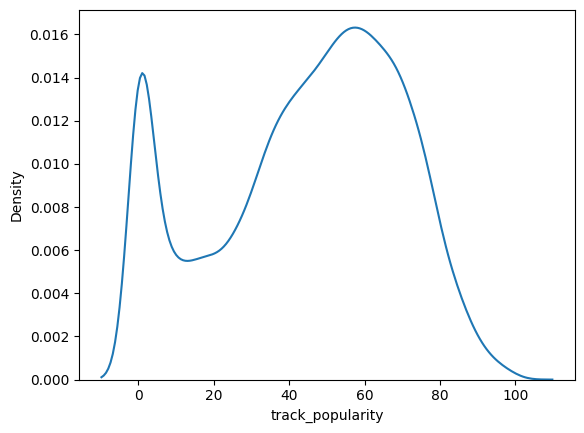

In [ ]:
sns.kdeplot(df['track_popularity'])

#### Modelo

In [ ]:
df.columns.to_list()[0]

'Unnamed: 0'

In [ ]:
cols = ['Unnamed: 0','track_artist', 'playlist_name', 'playlist_id',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'grupo_anio',
       'distance_mean_danceability', 'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age', 'len_playlist_name',
       'log_instrumentalness', 'log_speechiness', 'log_liveness', 'z_danceability', 'z_energy', 'z_loudness', 'z_tempo',
       'z_valence', 'z_acousticness', 'z_instrumentalness', 'z_speechiness',
       'global_atipicality', 'max_z_score',
       'most_extreme_feature', 'mood_score', 'chill_score', 'melancholy_score',
       'radio_friendly', 'club_score', 'acoustic_contrast', 'mood_complexity',
       'dance_val_tension', 'vocal_presence', 'pure_instrumental',
       'spoken_word', 'loudness_abs', 'loudness_energy_ratio',
       'dynamic_compression', 'live_vocal', 'studio_clean', 'danceability_sq',
       'danceability_sqrt', 'energy_sq', 'energy_sqrt', 'valence_sq',
       'valence_sqrt', 'loudness_abs_sq', 'loudness_abs_sqrt', 'tonality']

dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
genre_imp = dummies_genre[['r&b']]
subgenre_imp = dummies_subgenre[['neo soul']]

copia = df.copy()

df_1 = pd.concat([copia[cols], genre_imp, subgenre_imp], axis=1)

df_1['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df_1['distance_sq_mean_duration_min'] = (df_1['distance_mean_duration_min'])**2
df_1['log_duration_min'] = np.log(df['duration_min'])
df_1['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

In [ ]:
df_1.head(1)

,Unnamed: 0,track_artist,playlist_name,playlist_id,danceability,energy,key,loudness,mode,speechiness,...,valence_sqrt,loudness_abs_sq,loudness_abs_sqrt,tonality,r&b,neo soul,distance_mean_duration_min,distance_sq_mean_duration_min,log_duration_min,z_duration_min
0,0,brDyePD9ftuUV+4Gnr1FJsWPjK4BxX5b0XyoYraitMs=,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,0.748,0.916,6,-2.634,1,0.0583,...,0.719722,6.937956,1.62296,6_1,0,0,-0.515945,0.266199,1.177393,-0.576913


In [ ]:
df_1['r&b'] = df_1['r&b'].astype(str)
df_1['neo soul'] = df_1['neo soul'].astype(str)

In [ ]:
X = df_1.copy()
y = df['track_popularity'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_true, X_val, y_train_true, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
cat_features = df_1.select_dtypes(include='object').columns.tolist()

In [ ]:
train_pool = Pool(X_train_true, y_train_true, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = model.predict(X_train_true)
print(f"R²:   {r2_score(y_train_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_true, y_pred)):.4f}")

print('VAL')
y_pred = model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 24.8578501	test: 24.5155207	best: 24.5155207 (0)	total: 125ms	remaining: 2m 4s
100:	learn: 19.8173938	test: 19.1184236	best: 19.1184236 (100)	total: 6.21s	remaining: 55.3s
200:	learn: 19.1512754	test: 18.6589414	best: 18.6586568 (199)	total: 15.7s	remaining: 1m 2s
300:	learn: 18.8198895	test: 18.4843737	best: 18.4843737 (300)	total: 23s	remaining: 53.5s
400:	learn: 18.5665537	test: 18.3649474	best: 18.3649050 (399)	total: 30.1s	remaining: 44.9s
500:	learn: 18.3072956	test: 18.2806245	best: 18.2806245 (500)	total: 36.8s	remaining: 36.7s
600:	learn: 18.0976842	test: 18.2360256	best: 18.2360256 (600)	total: 44.9s	remaining: 29.8s
700:	learn: 17.9037655	test: 18.2089153	best: 18.2089153 (700)	total: 50.9s	remaining: 21.7s
800:	learn: 17.7294545	test: 18.1798909	best: 18.1798909 (800)	total: 59.4s	remaining: 14.8s
900:	learn: 17.5579516	test: 18.1542714	best: 18.1538900 (899)	total: 1m 5s	remaining: 7.2s
999:	learn: 17.4083116	test: 18.1366154	best: 18.1351692 (991)	total: 1m 12s	

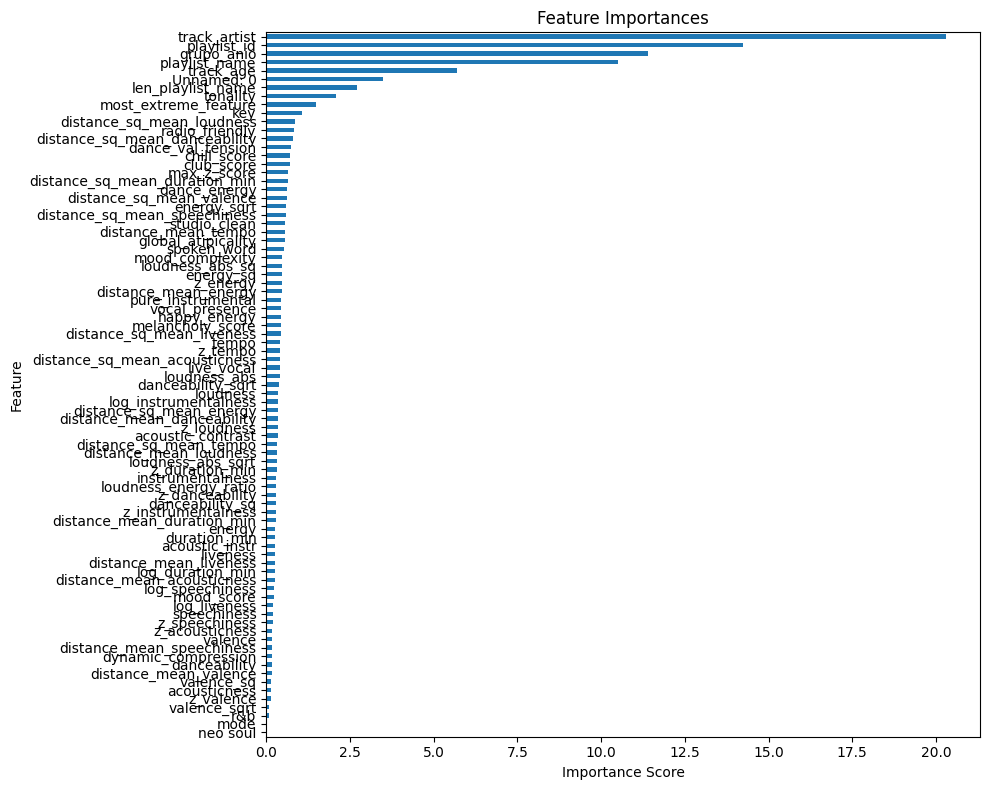

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(feature_importances.sort_values(ascending=False)).T

,track_artist,playlist_id,grupo_anio,playlist_name,track_age,Unnamed: 0,len_playlist_name,tonality,most_extreme_feature,key,...,dynamic_compression,danceability,distance_mean_valence,valence_sq,acousticness,z_valence,valence_sqrt,r&b,mode,neo soul
0,20.29969,14.232521,11.398564,10.492554,5.682444,3.476233,2.697562,2.075621,1.490097,1.068101,...,0.16509,0.160049,0.158877,0.139115,0.132402,0.127847,0.08142,0.074141,0.016001,0.0


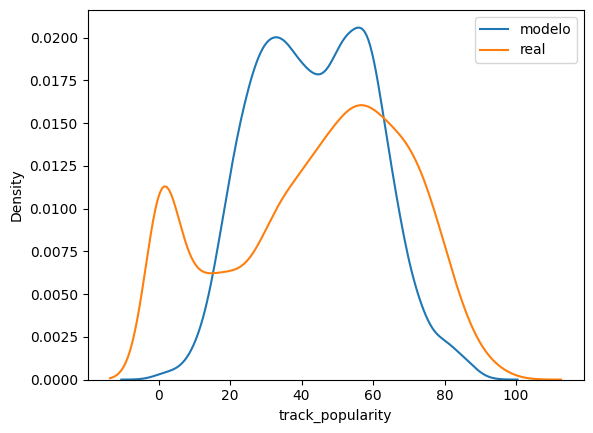

In [ ]:
sns.kdeplot(model.predict(X_test), label='modelo')
sns.kdeplot(df.loc[X_test['Unnamed: 0'].values, 'track_popularity'], label='real')
plt.legend()
plt.show()

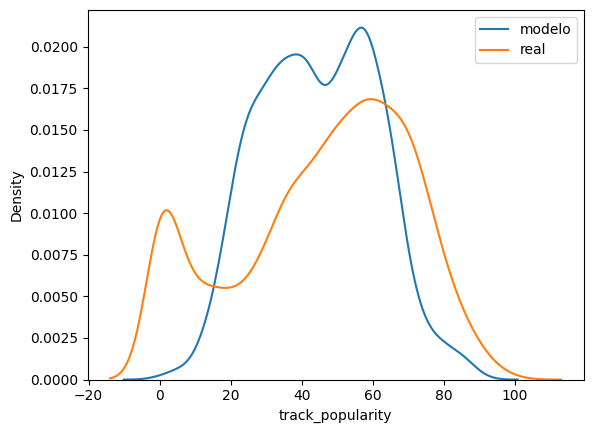

In [ ]:
sns.kdeplot(model.predict(X_val), label='modelo')
sns.kdeplot(df.loc[X_val['Unnamed: 0'].values, 'track_popularity'], label='real')
plt.legend()
plt.show()

### Submission

In [ ]:
df_val_ML = df_val.copy()
df_val_ML = df_val_ML[cols]

df_val_ML['r&b'] = (df_val['playlist_genre'] == 'r&b').astype(int).rename('r&b')
df_val_ML['neo soul'] = (df_val['playlist_subgenre'] == 'neo soul').astype(int).rename('neo soul')
df_val_ML['distance_mean_duration_min'] = (df_val_ML['duration_min'] - df['duration_min'].mean())
df_val_ML['distance_sq_mean_duration_min'] = (df_val_ML['distance_mean_duration_min'])**2
df_val_ML['log_duration_min'] = np.log(df['duration_min'])
df_val_ML['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()
df_val_ML['r&b'] = df_val_ML['r&b'].astype(str)
df_val_ML['neo soul'] = df_val_ML['neo soul'].astype(str)

df_val_ML = df_val_ML[df_1.columns.tolist()]

In [ ]:
y_val_pred = model.predict(df_val_ML)

In [ ]:
best_sub = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

Hacemos modelo entrenado - 5

In [ ]:
submission_modelo = pd.DataFrame({
    'ID': df_val_ML['Unnamed: 0'],
    'track_popularity': y_val_pred
})

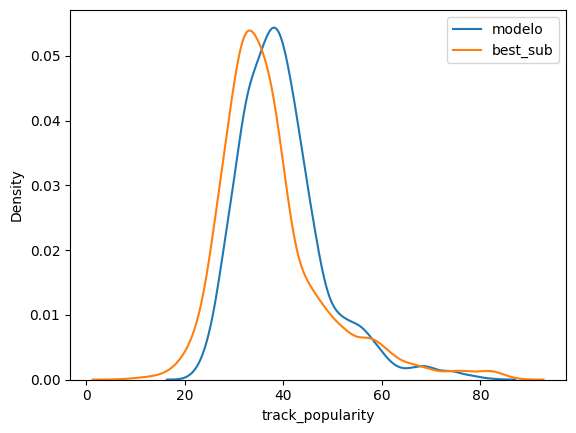

In [ ]:
sns.kdeplot(submission_modelo['track_popularity'], label='modelo')
sns.kdeplot(best_sub['track_popularity'], label='best_sub')
plt.legend()
plt.show()

In [ ]:
submission_modelo_menos6 = pd.DataFrame({
    'ID': df_val_ML['Unnamed: 0'],
    'track_popularity': y_val_pred
})
submission_modelo_menos6['track_popularity'] = submission_modelo_menos6['track_popularity'] - 6
submission_modelo_menos6['track_popularity'] = submission_modelo_menos6['track_popularity'].clip(lower=0)

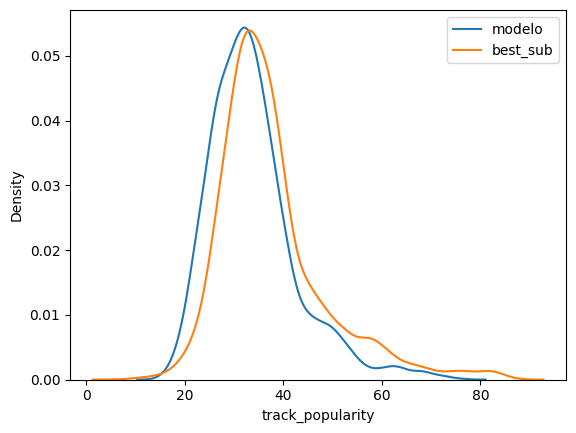

In [ ]:
sns.kdeplot(submission_modelo_menos6['track_popularity'], label='modelo')
sns.kdeplot(best_sub['track_popularity'], label='best_sub')
plt.legend()
plt.show()

In [ ]:
submission_modelo_menos6.to_csv('catboost_full_modelo_menos6.csv', index=False)

Imputamos por track_id y track_name promedio

In [ ]:
# Calculate the average track_popularity for each track_id in df
track_popularity_avg_df = df.groupby('track_id')['track_popularity'].mean()

# Populate y_val_predicted_track_id_avg by mapping track_id from df_val
# The index of the resulting Series will be df_val['Unnamed: 0'], and values will be
# the average popularity if a track_id match is found, otherwise NaN.
y_val_predicted_track_id_avg = df_val.set_index('Unnamed: 0')['track_id'].map(track_popularity_avg_df)

# The variable y_val_predicted_track_id_avg now contains the desired predictions,
# correctly indexed by 'Unnamed: 0' and with NaNs where track_id was not found in df.

# Ensure y_val_pred has the same index as df_val['Unnamed: 0'] for proper alignment
y_val_pred_series = pd.Series(y_val_pred, index=df_val['Unnamed: 0'])


# Combine the two prediction series:
# If y_val_predicted_track_id_avg_aligned has a value (not NaN), use it.
# Otherwise, use the value from y_val_pred_series.
y_val_combined_predictions = y_val_predicted_track_id_avg.fillna(y_val_pred_series)

# Create a DataFrame for the final predictions, ensuring 'ID' matches 'Unnamed: 0' from df_val
# y_val_combined_predictions is already indexed by the 'Unnamed: 0' values.
# So, we can directly use its index for the 'ID' column and its values for 'track_popularity'.
submission_df_combined_track_id = pd.DataFrame({
    'ID': y_val_combined_predictions.index,
    'track_popularity_track_id': y_val_combined_predictions.values
})

print(submission_df_combined_track_id.head())

      ID  track_popularity_track_id
0  26266                  49.708712
1  26267                  51.212058
2  26268                  50.409857
3  26269                  42.384018
4  26270                  53.347035


In [ ]:
# Calculate the average track_popularity for each track_name in df
track_popularity_avg_df = df.groupby('track_name')['track_popularity'].mean()

# Populate y_val_predicted_track_name_avg by mapping track_name from df_val
# The index of the resulting Series will be df_val['Unnamed: 0'], and values will be
# the average popularity if a track_name match is found, otherwise NaN.
y_val_predicted_track_name_avg = df_val.set_index('Unnamed: 0')['track_name'].map(track_popularity_avg_df)

# The variable y_val_predicted_track_name_avg now contains the desired predictions,
# correctly indexed by 'Unnamed: 0' and with NaNs where track_name was not found in df.

# Ensure y_val_pred has the same index as df_val['Unnamed: 0'] for proper alignment
y_val_pred_series = pd.Series(y_val_pred, index=df_val['Unnamed: 0'])


# Combine the two prediction series:
# If y_val_predicted_track_name_avg_aligned has a value (not NaN), use it.
# Otherwise, use the value from y_val_pred_series.
y_val_combined_predictions = y_val_predicted_track_name_avg.fillna(y_val_pred_series)

# Create a DataFrame for the final predictions, ensuring 'ID' matches 'Unnamed: 0' from df_val
# y_val_combined_predictions is already indexed by the 'Unnamed: 0' values.
# So, we can directly use its index for the 'ID' column and its values for 'track_popularity'.
submission_df_combined_track_name = pd.DataFrame({
    'ID': y_val_combined_predictions.index,
    'track_popularity_track_name': y_val_combined_predictions.values
})

print(submission_df_combined_track_name.head())

      ID  track_popularity_track_name
0  26266                    49.708712
1  26267                    43.166667
2  26268                    50.409857
3  26269                    42.384018
4  26270                    53.347035


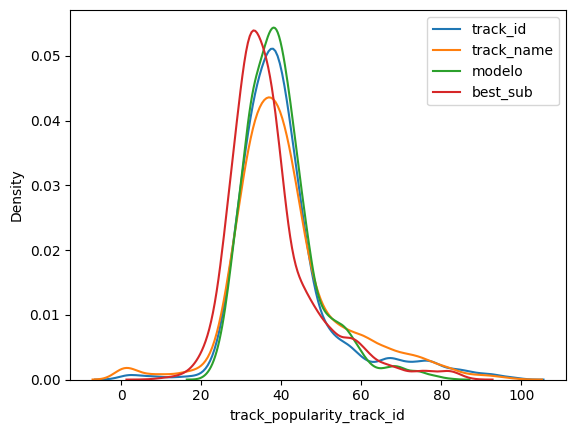

In [ ]:
sns.kdeplot(submission_df_combined_track_id['track_popularity_track_id'], label='track_id')
sns.kdeplot(submission_df_combined_track_name['track_popularity_track_name'], label='track_name')
sns.kdeplot(y_val_pred, label='modelo')
sns.kdeplot(best_sub['track_popularity'], label='best_sub')
plt.legend()
plt.show()

Submission track_name:

Kaggle Test -> 0,15843

In [ ]:
submission_df_combined_track_name.to_csv('catboost_full_track_name_imputation.csv', index=False)

Submission track_id - 5:

Kaggle Test -> 0,38978

In [ ]:
submission_df_combined_track_id['track_popularity'] = submission_df_combined_track_id['track_popularity_track_id'] - 5

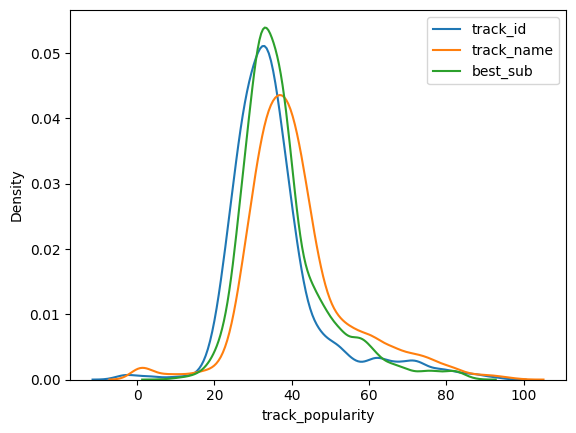

In [ ]:
sns.kdeplot(submission_df_combined_track_id['track_popularity'], label='track_id')
sns.kdeplot(submission_df_combined_track_name['track_popularity_track_name'], label='track_name')
sns.kdeplot(best_sub['track_popularity'], label='best_sub')
plt.legend()
plt.show()

In [ ]:
submission_df_combined_track_id[['ID','track_popularity']].to_csv('catboost_full_track_id_imputation_moved-5.csv', index=False)

In [ ]:
print(f'Hubieron {(submission_df_combined_track_id['track_popularity'] <0).sum()} predicciones menores a 0')
print('Hay que corregir eso')

Hubieron 26 predicciones menores a 0
Hay que corregir eso


Misma submission 8 unidades a la izquierda -> Bajamos de 0,38978 de que estaba movida en 5 unidades a 0,38898 de la que se movio

In [ ]:
submission_df_combined_track_id['track_popularity'] = submission_df_combined_track_id['track_popularity_track_id'] - 8
submission_df_combined_track_id['track_popularity'] = submission_df_combined_track_id['track_popularity'].clip(lower=0)

In [ ]:
submission_df_combined_track_id[['ID','track_popularity']].to_csv('catboost_full_track_id_imputation_moved-8.csv', index=False)

Misma submission (track_id) pero movida 3,75 y 6,25 unidades en vez de 8

In [ ]:
submission_track_id = pd.read_csv('/content/catboost_full_track_id_imputation_moved-5.csv')

In [ ]:
# Le sumamos 5 porque la que cargamos estaba movida 5 unidades a la izquierda
submission_track_id['track_popularity'] = submission_track_id['track_popularity'] + 5

In [ ]:
submission_track_id_menos_375 = pd.DataFrame({
    'ID': submission_track_id['ID'],
    'track_popularity': submission_track_id['track_popularity'] - 3.75
})

submission_track_id_menos_375['track_popularity'] = submission_track_id_menos_375['track_popularity'].clip(lower=0)

submission_track_id_menos_375[['ID','track_popularity']].to_csv('catboost_full_track_id_imputation_moved-3.75.csv', index=False)

In [ ]:
submission_track_id_menos_625 = pd.DataFrame({
    'ID': submission_track_id['ID'],
    'track_popularity': submission_track_id['track_popularity'] - 6.25
})

submission_track_id_menos_625['track_popularity'] = submission_track_id_menos_625['track_popularity'].clip(lower=0)

submission_track_id_menos_625[['ID','track_popularity']].to_csv('catboost_full_track_id_imputation_moved-6.25.csv', index=False)

Muevo 6.25 unidades las predicciones de track_name -> Pasamos de 0,15843 de la original a 0,24732 de la que movi

In [ ]:
submission = pd.read_csv('/content/catboost_full_track_name_imputation.csv')

In [ ]:
submission['track_popularity'] = submission['track_popularity_track_name'] - 6.25
submission['track_popularity'] = submission['track_popularity'].clip(lower=0)

submission[['ID','track_popularity']].to_csv('catboost_full_track_name_imputation_moved-6.25.csv', index=False)

## Prueba II

Parte Uno: hacemos un modelo solo con canciones que compartan alguna caracteristica del track con val

Parte Dos: combinamos ese modelo con que reemplace la track popularity con la del train si es que coinciden

In [ ]:
condicion1 = (df['track_album_name'].isin(set(df['track_album_name'].values) & set(df_val['track_album_name'].values)))

condicion2 = (df['track_album_id'].isin(set(df['track_album_id'].values) & set(df_val['track_album_id'].values)))

condicion3 = (df['track_artist'].isin(set(df['track_artist'].values) & set(df_val['track_artist'].values)))

condicion4 = (df['track_name'].isin(set(df['track_name'].values) & set(df_val['track_name'].values)))

condicion5 = (df['track_id'].isin(set(df['track_id'].values) & set(df_val['track_id'].values)))

In [ ]:
for i in ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name','playlist_name', 'playlist_id']:
  print(f'COL {i}')
  print(df[condicion1 | condicion2 | condicion3 | condicion4 | condicion5][i].value_counts())
  print()

COL track_id
track_id
+KgsqkDoJhtoNtm9sU4quanJCGKxTYpU5Kf0GgHorveV0zO0KRYKE/GrUqRBhCax    9
fjNjx9p40U67FpY6pEgwhQwOBi7QXXy66Ig5OvmfbL8VS4X0u3AIs/jDPLMbxZ9V    8
xiMJX8RtqX0g+1hHWDWDxTnQ8ZrKuypNSDQ82KQHkTCWpuRD5qc4qqK/gYo7Syui    8
RCddfWDQ8ll6zWEkYs9r2uGoMbktd2lI6kx7/6izDXfUkvDNkxjCcpsrrLyRQ5h0    7
Ar9QoVhY/mxqqA0nctnql+oZ6oK0IFfRcv0P3YQNcBR9SIsLzSWs1vyUyWqoRZDv    7
                                                                   ..
HEDajitOK47v0exWd6HwZ1uVAdHLja9ZrHs6GORg8jl0obSB9HQgaByNMj8GEw9X    1
NyuJKV9NiAzEQTYnY+yymj3GJjea+/j8K+AnGFc2hFIOO+gXZ/SY6z6Yz6+HcxSB    1
8jiZfaYPTDScl98nQ1uWK/LyaasJY2jpt5ajt001o1R9E9lSvdVLto7hoUSPHtnw    1
6kBf5m+naV/RX+ER8OsQ6k+XyxcPMRi7lri3TEq6s8RfV/TDu3Oi9hwG1JPNek8M    1
YQf/ptFuMel28YEyNjFE71RvdCHlscy7+NK9ZKEYl3Ar487bZDlC2l48CE+PVUJf    1
Name: count, Length: 6077, dtype: int64

COL track_name
track_name
7Rao2wyZ1svIYk+8weL9gbSHmRKK6LibsDexKUjKSN8=                        20
zKFJoiI1LlBKvQy4/XxQJUwHzIVB+DQ36NZn0nB2hN0=                        15

In [ ]:
df_reduced = df[condicion1 | condicion2 | condicion3 | condicion4 | condicion5].copy()

In [ ]:
columns_to_check = ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name']

shared_features_count = 0
for index_val, row_val in df_val.iterrows():
    found_match = False
    for col in columns_to_check:
        if row_val[col] in df[col].values:
            found_match = True
            break
    if found_match:
        shared_features_count += 1

print(f"Total songs in df_val: {len(df_val)}")
print(f"Songs in df_val sharing at least one feature with df: {shared_features_count}")
if shared_features_count == len(df_val):
    print("All songs in df_val share at least one characteristic with df.")
else:
    print(f"{len(df_val) - shared_features_count} songs in df_val do not share any of the specified characteristics with df.")

Total songs in df_val: 6567
Songs in df_val sharing at least one feature with df: 3940
2627 songs in df_val do not share any of the specified characteristics with df.


In [ ]:
cols = ['track_artist',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'grupo_anio',
       'distance_mean_danceability', 'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness',
        'distance_mean_tempo',
       'distance_sq_mean_tempo', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age', 'len_playlist_name',
       'log_instrumentalness', 'log_speechiness', 'log_liveness', 'z_danceability', 'z_energy', 'z_loudness', 'z_tempo',
        'z_acousticness', 'z_instrumentalness', 'z_speechiness',
       'global_atipicality', 'max_z_score',
       'most_extreme_feature', 'mood_score', 'chill_score', 'melancholy_score',
       'radio_friendly', 'club_score', 'acoustic_contrast', 'mood_complexity',
       'dance_val_tension', 'vocal_presence', 'pure_instrumental',
       'spoken_word', 'loudness_abs', 'loudness_energy_ratio',
        'live_vocal', 'studio_clean', 'danceability_sq',
       'danceability_sqrt', 'energy_sq', 'energy_sqrt',
       'loudness_abs_sq', 'loudness_abs_sqrt', 'tonality']

# Sacamos  'valence_sqrt','valence_sq','distance_sq_mean_valence','z_valence','distance_mean_valence','danceability', 'dynamic_compression',

dummies_genre = pd.get_dummies(df_reduced['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df_reduced['playlist_subgenre']).astype(int)
genre_imp = dummies_genre.loc[df_reduced.index.values.tolist(), ['r&b']]
subgenre_imp = dummies_subgenre.loc[df_reduced.index.values.tolist(),['neo soul']]

copia = df_reduced.copy()

df_2 = pd.concat([copia[cols], genre_imp, subgenre_imp], axis=1)

df_2['distance_mean_duration_min'] = (df_2['duration_min'] - df['duration_min'].mean())
df_2['distance_sq_mean_duration_min'] = (df_2['distance_mean_duration_min'])**2
df_2['log_duration_min'] = np.log(df['duration_min'])
df_2['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()
df_2['r&b'] = df_2['r&b'].astype(str)
df_2['neo soul'] = df_2['neo soul'].astype(str)

In [ ]:
df_2.head(1)

,track_artist,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,energy_sqrt,loudness_abs_sq,loudness_abs_sqrt,tonality,r&b,neo soul,distance_mean_duration_min,distance_sq_mean_duration_min,log_duration_min,z_duration_min
0,brDyePD9ftuUV+4Gnr1FJsWPjK4BxX5b0XyoYraitMs=,0.916,6,-2.634,1,0.0583,0.102,0.0,0.0653,0.518,...,0.957079,6.937956,1.62296,6_1,0,0,-0.515945,0.266199,1.177393,-0.576913


In [ ]:
X = df_2.copy()
y = df.loc[df_reduced.index.values.tolist(), 'track_popularity'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train_true, X_val, y_train_true, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [ ]:
cat_features = df_2.select_dtypes(include='object').columns.tolist()

In [ ]:
train_pool = Pool(X_train_true, y_train_true, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = model.predict(X_train_true)
print(f"R²:   {r2_score(y_train_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_true, y_pred)):.4f}")

print('VAL')
y_pred = model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 26.3072460	test: 26.3174698	best: 26.3174698 (0)	total: 142ms	remaining: 2m 22s
100:	learn: 21.3367263	test: 21.3899747	best: 21.3899747 (100)	total: 3.18s	remaining: 28.3s
200:	learn: 20.5542626	test: 20.9941649	best: 20.9941649 (200)	total: 6.08s	remaining: 24.2s
300:	learn: 20.0088829	test: 20.8587588	best: 20.8587588 (300)	total: 10.3s	remaining: 24s
400:	learn: 19.5018160	test: 20.7349078	best: 20.7331468 (398)	total: 13.3s	remaining: 19.8s
500:	learn: 19.0073706	test: 20.6643149	best: 20.6632253 (496)	total: 16.2s	remaining: 16.1s
600:	learn: 18.5556829	test: 20.5872404	best: 20.5855602 (598)	total: 19.2s	remaining: 12.7s
700:	learn: 18.1577010	test: 20.5209709	best: 20.5195573 (691)	total: 23.4s	remaining: 10s
800:	learn: 17.7889600	test: 20.4866525	best: 20.4838616 (795)	total: 26.4s	remaining: 6.57s
900:	learn: 17.4517599	test: 20.4457945	best: 20.4435903 (883)	total: 29.3s	remaining: 3.22s
999:	learn: 17.1279284	test: 20.4000628	best: 20.3997673 (993)	total: 32.2s	r

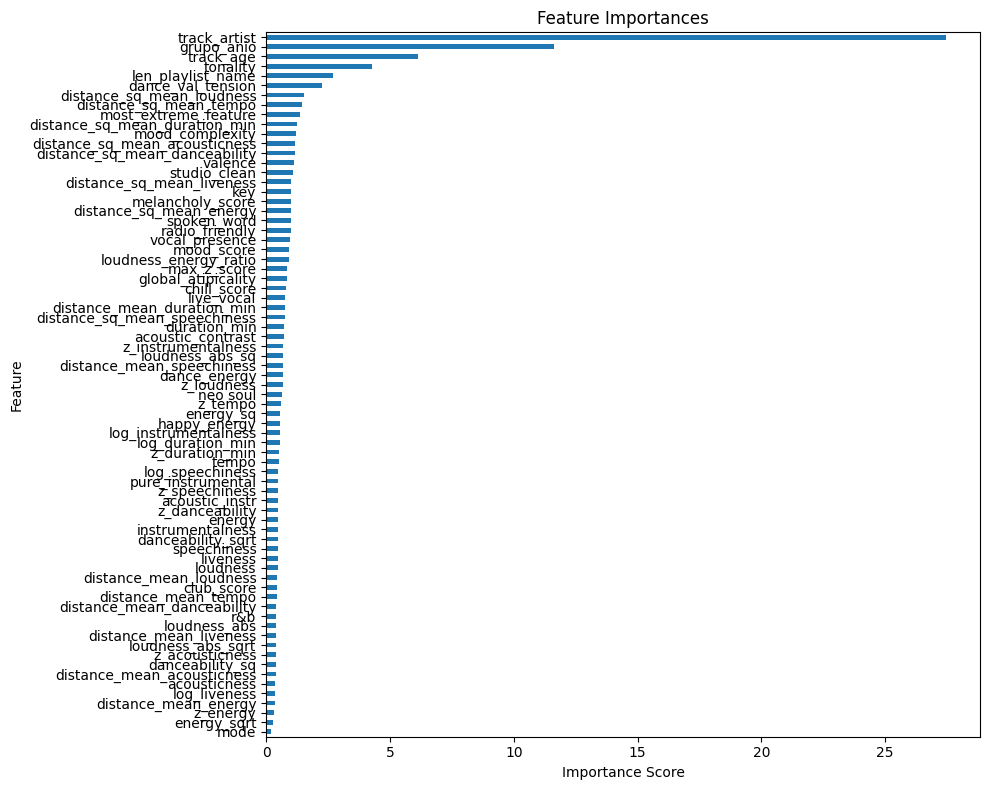

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(feature_importances.sort_values(ascending=False)).T

,track_artist,grupo_anio,track_age,tonality,len_playlist_name,dance_val_tension,distance_sq_mean_loudness,distance_sq_mean_tempo,most_extreme_feature,distance_sq_mean_duration_min,...,loudness_abs_sqrt,z_acousticness,danceability_sq,distance_mean_acousticness,acousticness,log_liveness,distance_mean_energy,z_energy,energy_sqrt,mode
0,27.463498,11.606973,6.123015,4.275149,2.694959,2.243769,1.532251,1.4453,1.361826,1.253345,...,0.392791,0.386994,0.375527,0.375117,0.365481,0.362122,0.341631,0.300654,0.277176,0.196116


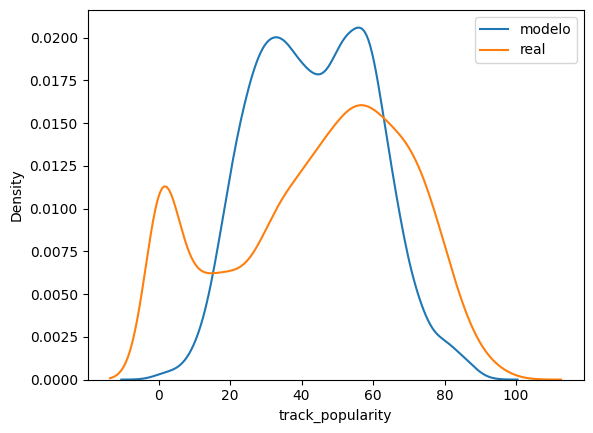

In [ ]:
sns.kdeplot(model.predict(X_test), label='modelo')
sns.kdeplot(df.loc[X_test['Unnamed: 0'].values, 'track_popularity'], label='real')
plt.legend()
plt.show()

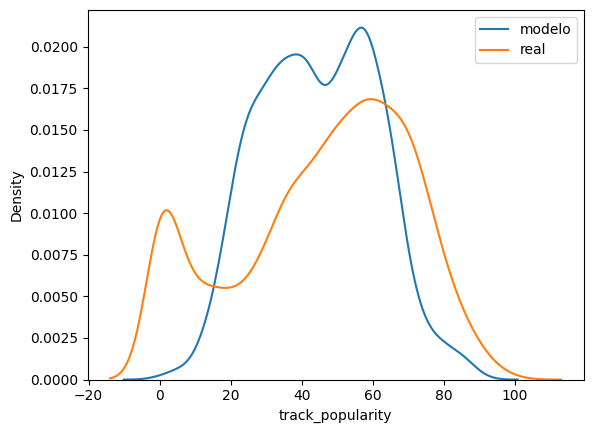

In [ ]:
sns.kdeplot(model.predict(X_val), label='modelo')
sns.kdeplot(df.loc[X_val['Unnamed: 0'].values, 'track_popularity'], label='real')
plt.legend()
plt.show()

### Submission

In [ ]:
df_val_ML = df_val.copy()
df_val_ML = df_val_ML[cols]

df_val_ML['r&b'] = (df_val['playlist_genre'] == 'r&b').astype(int).rename('r&b')
df_val_ML['neo soul'] = (df_val['playlist_subgenre'] == 'neo soul').astype(int).rename('neo soul')
df_val_ML['distance_mean_duration_min'] = (df_val_ML['duration_min'] - df['duration_min'].mean())
df_val_ML['distance_sq_mean_duration_min'] = (df_val_ML['distance_mean_duration_min'])**2
df_val_ML['log_duration_min'] = np.log(df['duration_min'])
df_val_ML['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()
df_val_ML['r&b'] = df_val_ML['r&b'].astype(str)
df_val_ML['neo soul'] = df_val_ML['neo soul'].astype(str)

df_val_ML = df_val_ML[df_2.columns.tolist()]

In [ ]:
y_val_predicted = model.predict(df_val_ML)

In [ ]:
y_val_predicted_current = y_val_predicted.copy()

columns_to_check = ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name']

# Create dictionaries for fast lookup of track_popularity in df based on each characteristic
df_popularity_maps = {}
for col in columns_to_check:
    # Use drop_duplicates to handle cases where the same characteristic value might appear multiple times
    # in df with potentially different popularity (taking the first one encountered).
    df_popularity_maps[col] = df.drop_duplicates(subset=[col]).set_index(col)['track_popularity'].to_dict()

# Initialize a Series to store the potentially overridden popularity from df
# Its index must align with df_val_ML and y_val_predicted
matched_df_popularity = pd.Series(np.nan, index=df_val.index)

# Iterate through the original df_val to check for matches
# We use df_val's index and iloc position to match with y_val_predicted
for i, (idx_val, row_val) in enumerate(df_val.iterrows()):
    # If this row in df_val hasn't found a match yet (NaN in matched_df_popularity),
    # try to find one. This avoids overwriting an existing match from an earlier column.
    if pd.isna(matched_df_popularity.loc[idx_val]):
        for col in columns_to_check:
            value_to_check = row_val[col]
            if value_to_check in df_popularity_maps[col]:
                matched_df_popularity.loc[idx_val] = df_popularity_maps[col][value_to_check]
                break # Stop checking other columns for this row once a match is found

# Combine model predictions with the manually found popularity
# Where matched_df_popularity is not NaN, use its value; otherwise, use the model's prediction.
# It's crucial that y_val_predicted is aligned with df_val.index positions.
y_val_predicted_series = pd.Series(y_val_predicted_current, index=df_val.index)
y_val_predicted_final = matched_df_popularity.fillna(y_val_predicted_series).values

# The variable y_val_predicted_final now holds the adjusted predictions.

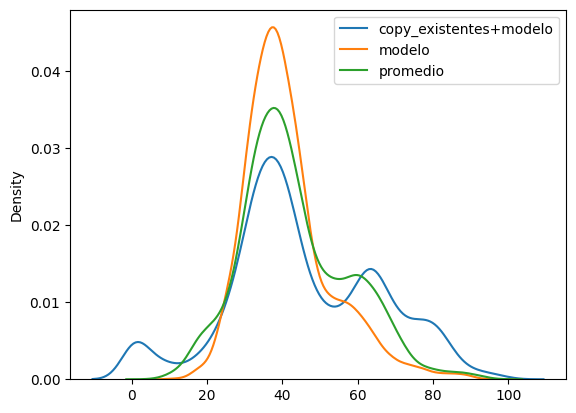

In [ ]:
sns.kdeplot(y_val_predicted_final, label='copy_existentes+modelo')
sns.kdeplot(y_val_predicted, label='modelo')
sns.kdeplot((y_val_predicted+y_val_predicted_final)/2, label='promedio')
plt.legend()
plt.show()

In [ ]:
submission_df_cb = pd.DataFrame({
    'ID': list(df_val['Unnamed: 0']),
    'track_popularity': y_val_predicted_final
})

submission_df_cb.to_csv('submission_catboost_reduced_track_data_with_copy.csv', index=False)

Comparacion con el mejor resultado

In [ ]:
best_sub = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

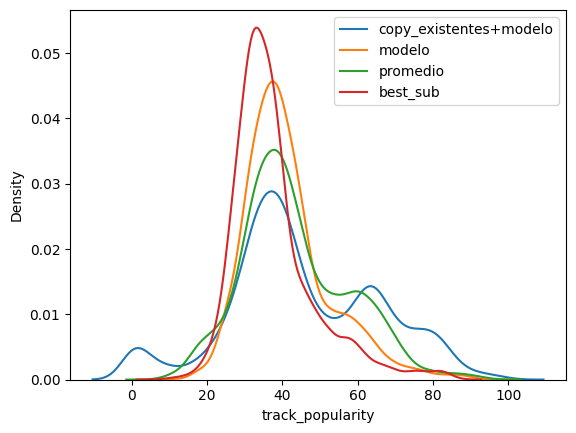

In [ ]:
sns.kdeplot(y_val_predicted_final, label='copy_existentes+modelo')
sns.kdeplot(y_val_predicted, label='modelo')
sns.kdeplot((y_val_predicted+y_val_predicted_final)/2, label='promedio')
sns.kdeplot(best_sub['track_popularity'], label='best_sub')
plt.legend()
plt.show()

In [ ]:
comparacion = pd.DataFrame({'best_sub': best_sub['track_popularity'], 'copy_existentes+modelo': y_val_predicted_final})
comparacion['diferencia'] = comparacion['best_sub'] - comparacion['copy_existentes+modelo']

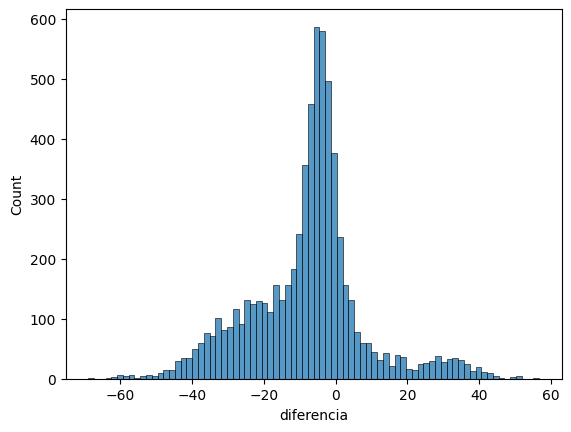

In [ ]:
sns.histplot(comparacion['diferencia'])
plt.show()